# Challenge 01 Tuned: K-nearest neighbors

## Objective

This notebook is intentionally designed for a heavier search budget.
The goal is to push the selected model beyond the previous local baseline using a two-stage search:

1. A broad coarse search across the most promising region.
2. A fine search built automatically around the best coarse configuration.

These notebooks are expected to take substantially longer than the `Ready` versions.
They are prepared for manual execution and are not guaranteed to exceed 0.90, but they are explicitly configured to chase that target as hard as this model family reasonably allows.

## 0. Load libraries

In [1]:
from pathlib import Path
import json
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.decomposition import PCA
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, confusion_matrix
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["savefig.bbox"] = "tight"

RANDOM_STATE = 301655
OUTER_TEST_SIZE = 0.20
SEARCH_CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

## 1. Configure the model family and the coarse search space

In [2]:
from sklearn.neighbors import KNeighborsClassifier

MODEL_NAME = "K-nearest neighbors"
NOTEBOOK_SLUG = "challenge_01_knn_tuned"
BASELINE_REFERENCE = {
    "previous_local_best_validation_accuracy": 0.8285,
    "goal": "Push KNN beyond the current local baseline and explore whether 0.90 is reachable."
}

COARSE_PIPELINE = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("pca", PCA(random_state=RANDOM_STATE)),
        ("model", KNeighborsClassifier()),
    ]
)

COARSE_GRID = {
    "pca__n_components": [36, 40, 44, 48, 52, 56, 60],
    "model__n_neighbors": [1, 2, 3, 4, 5, 6, 8, 10],
    "model__weights": ["uniform", "distance"],
    "model__metric": ["manhattan", "euclidean", "chebyshev"],
}

## 2. Load the challenge data

In [3]:
BASE_DIR = Path.cwd()
TRAIN_PATH = BASE_DIR / "data" / "training.csv"
TEST_PATH = BASE_DIR / "data" / "test.csv"
SAMPLE_PATH = BASE_DIR / "data" / "sample.csv"

train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)
sample_df = pd.read_csv(SAMPLE_PATH)

X = train_df.drop(columns=["id", "class"])
y = train_df["class"]
X_test_kaggle = test_df.drop(columns=["id"])

output_dir = BASE_DIR / "output" / NOTEBOOK_SLUG
output_dir.mkdir(parents=True, exist_ok=True)

submission_dir = BASE_DIR / "submissions"
submission_dir.mkdir(parents=True, exist_ok=True)

def save_current_figure(filename: str) -> Path:
    path = output_dir / filename
    plt.tight_layout()
    plt.savefig(path, dpi=200)
    return path

def evaluate_predictions(y_true: pd.Series, y_pred: np.ndarray) -> dict:
    cm = confusion_matrix(y_true, y_pred)
    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "confusion_matrix": cm.tolist(),
    }

## 3. Quick audit of the dataset

In [4]:
print("Training shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("Sample submission shape:", sample_df.shape)
print("\nClass balance:")
display(train_df["class"].value_counts().sort_index())

print("\nMissing values in training:", int(train_df.isna().sum().sum()))
print("Missing values in test:", int(test_df.isna().sum().sum()))
print("Duplicated training rows:", int(train_df.duplicated().sum()))

Training shape: (10000, 202)
Test shape: (3000, 201)
Sample submission shape: (3000, 2)

Class balance:


class
0    5000
1    5000
Name: count, dtype: int64


Missing values in training: 0
Missing values in test: 0
Duplicated training rows: 0


## 4. PCA diagnostic

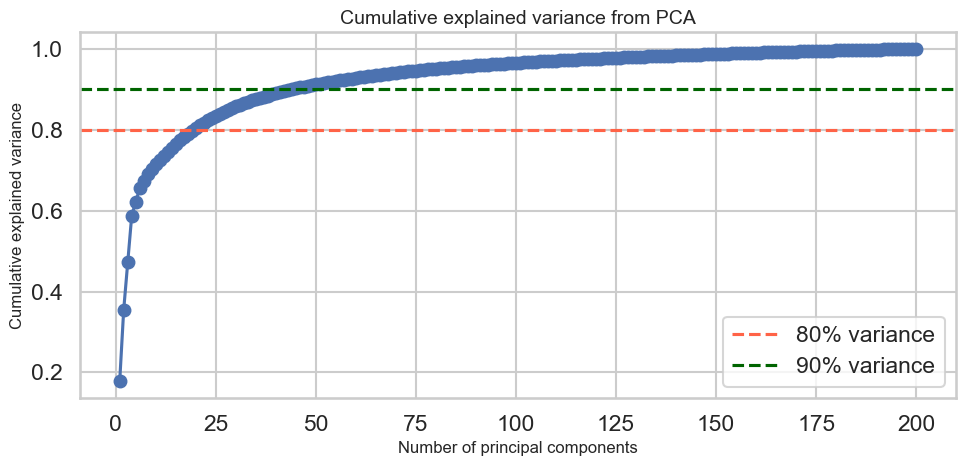

Saved figure: /Users/williamfrankmonroymamani/Documents/mem/stadistics/mem-estadistics/challenge/output/challenge_01_knn_tuned/pca_cumulative_variance.png
Components for 80% variance: 20
Components for 90% variance: 44


In [5]:
scaler_for_pca = StandardScaler()
X_scaled_full = scaler_for_pca.fit_transform(X)

pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_scaled_full)
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(10, 5))
plt.plot(np.arange(1, len(cumulative_variance) + 1), cumulative_variance, marker="o")
plt.axhline(0.80, color="tomato", linestyle="--", label="80% variance")
plt.axhline(0.90, color="darkgreen", linestyle="--", label="90% variance")
plt.title("Cumulative explained variance from PCA")
plt.xlabel("Number of principal components")
plt.ylabel("Cumulative explained variance")
plt.legend()
pca_variance_path = save_current_figure("pca_cumulative_variance.png")
plt.show()

print(f"Saved figure: {pca_variance_path}")
print("Components for 80% variance:", int(np.argmax(cumulative_variance >= 0.80) + 1))
print("Components for 90% variance:", int(np.argmax(cumulative_variance >= 0.90) + 1))

## 5. Create training and validation splits

In [6]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=OUTER_TEST_SIZE,
    stratify=y,
    random_state=RANDOM_STATE,
)

print("Training split:", X_train.shape, y_train.shape)
print("Validation split:", X_valid.shape, y_valid.shape)

Training split: (8000, 200) (8000,)
Validation split: (2000, 200) (2000,)


## 6. Coarse search

In [7]:
coarse_search = GridSearchCV(
    estimator=COARSE_PIPELINE,
    param_grid=COARSE_GRID,
    scoring="accuracy",
    cv=SEARCH_CV,
    n_jobs=1,
    refit=True,
    verbose=2,
)

coarse_search.fit(X_train, y_train)

print("Coarse best CV accuracy:", round(coarse_search.best_score_, 4))
print("Coarse best params:")
print(coarse_search.best_params_)

coarse_results = (
    pd.DataFrame(coarse_search.cv_results_)
    .sort_values("rank_test_score")
    .reset_index(drop=True)
)
display(coarse_results.loc[:, ["rank_test_score", "mean_test_score", "std_test_score", "params"]].head(10))
coarse_results.to_csv(output_dir / "coarse_cv_results.csv", index=False)

Fitting 5 folds for each of 336 candidates, totalling 1680 fits
[CV] END model__metric=manhattan, model__n_neighbors=1, model__weights=uniform, pca__n_components=36; total time=   0.1s
[CV] END model__metric=manhattan, model__n_neighbors=1, model__weights=uniform, pca__n_components=36; total time=   0.1s
[CV] END model__metric=manhattan, model__n_neighbors=1, model__weights=uniform, pca__n_components=36; total time=   0.1s
[CV] END model__metric=manhattan, model__n_neighbors=1, model__weights=uniform, pca__n_components=36; total time=   0.1s
[CV] END model__metric=manhattan, model__n_neighbors=1, model__weights=uniform, pca__n_components=36; total time=   0.1s
[CV] END model__metric=manhattan, model__n_neighbors=1, model__weights=uniform, pca__n_components=40; total time=   0.1s
[CV] END model__metric=manhattan, model__n_neighbors=1, model__weights=uniform, pca__n_components=40; total time=   0.2s
[CV] END model__metric=manhattan, model__n_neighbors=1, model__weights=uniform, pca__n_co

,rank_test_score,mean_test_score,std_test_score,params
0,1,0.795625,0.006755,"{'model__metric': 'manhattan', 'model__n_neigh..."
1,2,0.794625,0.003368,"{'model__metric': 'manhattan', 'model__n_neigh..."
2,3,0.794000,0.005911,"{'model__metric': 'manhattan', 'model__n_neigh..."
3,4,0.792875,0.002257,"{'model__metric': 'manhattan', 'model__n_neigh..."
4,5,0.791750,0.007939,"{'model__metric': 'manhattan', 'model__n_neigh..."
5,5,0.791750,0.007939,"{'model__metric': 'manhattan', 'model__n_neigh..."
6,5,0.791750,0.007939,"{'model__metric': 'manhattan', 'model__n_neigh..."
7,8,0.791375,0.005987,"{'model__metric': 'manhattan', 'model__n_neigh..."
8,8,0.791375,0.005987,"{'model__metric': 'manhattan', 'model__n_neigh..."
9,8,0.791375,0.005987,"{'model__metric': 'manhattan', 'model__n_neigh..."


## 7. Build the fine search space around the best coarse configuration

In [8]:
best_components = coarse_search.best_params_["pca__n_components"]
best_k = coarse_search.best_params_["model__n_neighbors"]
best_metric = coarse_search.best_params_["model__metric"]
best_weights = coarse_search.best_params_["model__weights"]

candidate_components = sorted(
    {
        value
        for value in [
            best_components - 4,
            best_components - 2,
            best_components - 1,
            best_components,
            best_components + 1,
            best_components + 2,
            best_components + 4,
        ]
        if 12 <= value <= X_train.shape[1]
    }
)

candidate_neighbors = sorted(
    {
        value
        for value in [
            best_k - 2,
            best_k - 1,
            best_k,
            best_k + 1,
            best_k + 2,
            best_k + 4,
        ]
        if value >= 1
    }
)

candidate_metrics = sorted({best_metric, "manhattan", "euclidean"})
candidate_weights = sorted({best_weights, "uniform", "distance"})

FINE_PIPELINE = COARSE_PIPELINE
FINE_GRID = {
    "pca__n_components": candidate_components,
    "model__n_neighbors": candidate_neighbors,
    "model__weights": candidate_weights,
    "model__metric": candidate_metrics,
}

print("Fine grid:")
print(FINE_GRID)

Fine grid:
{'pca__n_components': [40, 42, 43, 44, 45, 46, 48], 'model__n_neighbors': [2, 3, 4, 5, 6, 8], 'model__weights': ['distance', 'uniform'], 'model__metric': ['euclidean', 'manhattan']}


## 8. Fine search

In [9]:
fine_search = GridSearchCV(
    estimator=FINE_PIPELINE,
    param_grid=FINE_GRID,
    scoring="accuracy",
    cv=SEARCH_CV,
    n_jobs=1,
    refit=True,
    verbose=2,
)

fine_search.fit(X_train, y_train)

print("Fine best CV accuracy:", round(fine_search.best_score_, 4))
print("Fine best params:")
print(fine_search.best_params_)

fine_results = (
    pd.DataFrame(fine_search.cv_results_)
    .sort_values("rank_test_score")
    .reset_index(drop=True)
)
display(fine_results.loc[:, ["rank_test_score", "mean_test_score", "std_test_score", "params"]].head(10))
fine_results.to_csv(output_dir / "fine_cv_results.csv", index=False)

search = fine_search

Fitting 5 folds for each of 168 candidates, totalling 840 fits
[CV] END model__metric=euclidean, model__n_neighbors=2, model__weights=distance, pca__n_components=40; total time=   0.0s
[CV] END model__metric=euclidean, model__n_neighbors=2, model__weights=distance, pca__n_components=40; total time=   0.0s
[CV] END model__metric=euclidean, model__n_neighbors=2, model__weights=distance, pca__n_components=40; total time=   0.0s
[CV] END model__metric=euclidean, model__n_neighbors=2, model__weights=distance, pca__n_components=40; total time=   0.0s
[CV] END model__metric=euclidean, model__n_neighbors=2, model__weights=distance, pca__n_components=40; total time=   0.1s
[CV] END model__metric=euclidean, model__n_neighbors=2, model__weights=distance, pca__n_components=42; total time=   0.0s
[CV] END model__metric=euclidean, model__n_neighbors=2, model__weights=distance, pca__n_components=42; total time=   0.1s
[CV] END model__metric=euclidean, model__n_neighbors=2, model__weights=distance, pc

,rank_test_score,mean_test_score,std_test_score,params
0,1,0.795625,0.006755,"{'model__metric': 'manhattan', 'model__n_neigh..."
1,2,0.795250,0.007056,"{'model__metric': 'manhattan', 'model__n_neigh..."
2,3,0.794500,0.005665,"{'model__metric': 'manhattan', 'model__n_neigh..."
3,4,0.794000,0.005911,"{'model__metric': 'manhattan', 'model__n_neigh..."
4,5,0.790875,0.007537,"{'model__metric': 'manhattan', 'model__n_neigh..."
5,6,0.790125,0.008085,"{'model__metric': 'manhattan', 'model__n_neigh..."
6,6,0.790125,0.008709,"{'model__metric': 'manhattan', 'model__n_neigh..."
7,8,0.789750,0.007274,"{'model__metric': 'manhattan', 'model__n_neigh..."
8,9,0.789250,0.009180,"{'model__metric': 'manhattan', 'model__n_neigh..."
9,10,0.789000,0.008316,"{'model__metric': 'manhattan', 'model__n_neigh..."


## 9. Visualize the fine-search surface

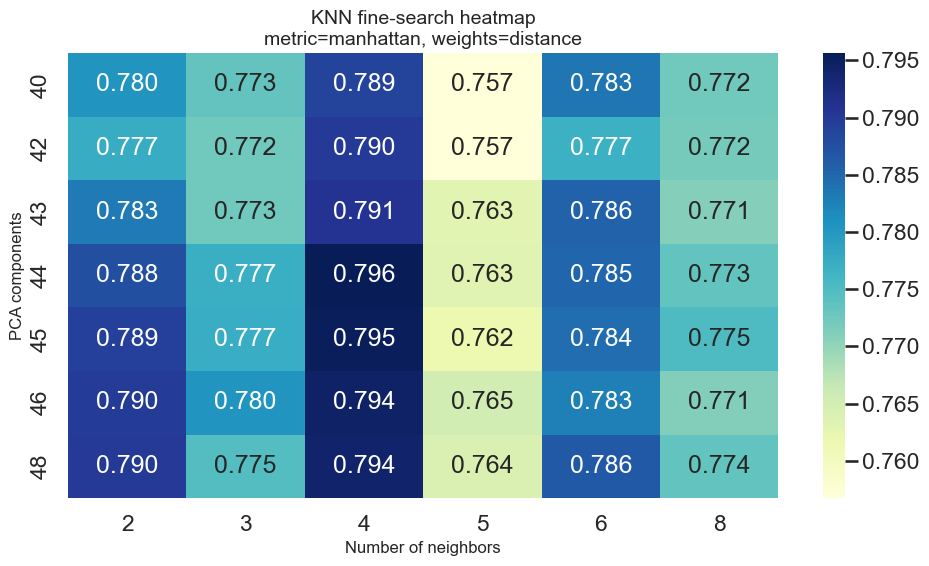

Saved figure: /Users/williamfrankmonroymamani/Documents/mem/stadistics/mem-estadistics/challenge/output/challenge_01_knn_tuned/knn_fine_heatmap.png


In [10]:
knn_results = fine_results.copy()
knn_results["pca__n_components"] = knn_results["param_pca__n_components"].astype(int)
knn_results["model__n_neighbors"] = knn_results["param_model__n_neighbors"].astype(int)
knn_results["model__weights"] = knn_results["param_model__weights"].astype(str)
knn_results["model__metric"] = knn_results["param_model__metric"].astype(str)

best_metric = knn_results.iloc[0]["model__metric"]
best_weight = knn_results.iloc[0]["model__weights"]

heatmap_data = (
    knn_results[
        (knn_results["model__metric"] == best_metric)
        & (knn_results["model__weights"] == best_weight)
    ]
    .pivot_table(
        index="pca__n_components",
        columns="model__n_neighbors",
        values="mean_test_score",
    )
    .sort_index()
)

plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_data, annot=True, fmt=".3f", cmap="YlGnBu")
plt.title(f"KNN fine-search heatmap\nmetric={best_metric}, weights={best_weight}")
plt.xlabel("Number of neighbors")
plt.ylabel("PCA components")
heatmap_path = save_current_figure("knn_fine_heatmap.png")
plt.show()

print(f"Saved figure: {heatmap_path}")

## 10. Evaluate the best tuned model on the holdout validation split

Validation accuracy: 0.822
Confusion matrix:
[[794 206]
 [150 850]]


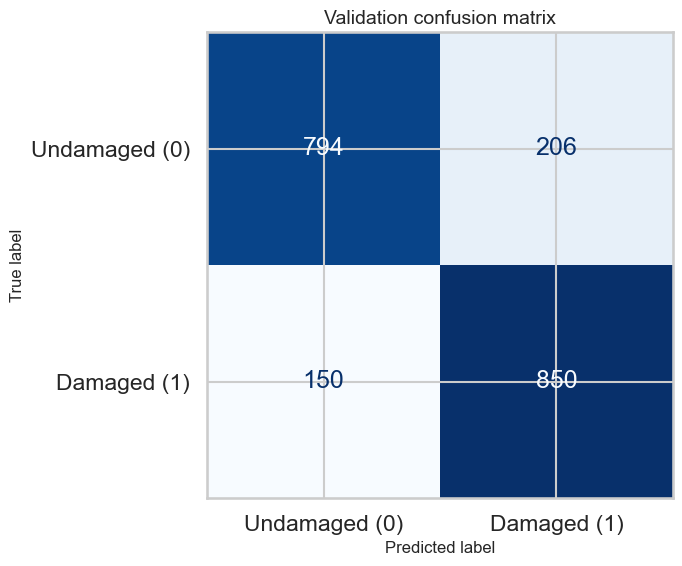

Saved figure: /Users/williamfrankmonroymamani/Documents/mem/stadistics/mem-estadistics/challenge/output/challenge_01_knn_tuned/validation_confusion_matrix.png


In [11]:
valid_predictions = search.predict(X_valid)
validation_report = evaluate_predictions(y_valid, valid_predictions)
validation_accuracy = validation_report["accuracy"]

print("Validation accuracy:", round(validation_accuracy, 4))
print("Confusion matrix:")
print(np.array(validation_report["confusion_matrix"]))

disp = ConfusionMatrixDisplay.from_predictions(
    y_valid,
    valid_predictions,
    display_labels=["Undamaged (0)", "Damaged (1)"],
    cmap="Blues",
    colorbar=False,
)
disp.ax_.set_title("Validation confusion matrix")
confusion_path = save_current_figure("validation_confusion_matrix.png")
plt.show()

print(f"Saved figure: {confusion_path}")

## Interpretation

KNN remains the strongest family found so far.
This notebook intentionally concentrates the search around the most promising region: low-to-mid numbers of neighbors, PCA in the 40-60 range, and distance metrics that performed better in previous runs.

## 11. Refit on the full training set and generate the submission file

In [12]:
final_model = search.best_estimator_
final_model.fit(X, y)
test_predictions = final_model.predict(X_test_kaggle)

submission_df = pd.DataFrame(
    {
        "id": test_df["id"],
        "class": test_predictions.astype(int),
    }
)

submission_path = submission_dir / f"{NOTEBOOK_SLUG}_submission.csv"
submission_df.to_csv(submission_path, index=False)
submission_df.head()

print(f"Submission saved to: {submission_path}")

Submission saved to: /Users/williamfrankmonroymamani/Documents/mem/stadistics/mem-estadistics/challenge/submissions/challenge_01_knn_tuned_submission.csv


## 12. Save the tuning summary

In [ ]:
summary_payload = {
    "model_name": MODEL_NAME,
    "strategy": "coarse_to_fine_grid_search",
    "baseline_reference": BASELINE_REFERENCE,
    "coarse_best_cv_accuracy": float(coarse_search.best_score_),
    "coarse_best_params": coarse_search.best_params_,
    "fine_best_cv_accuracy": float(fine_search.best_score_),
    "fine_best_params": fine_search.best_params_,
    "validation_accuracy": validation_accuracy,
    "output_dir": str(output_dir),
    "submission_path": str(submission_path),
}

summary_path = output_dir / "summary.json"
summary_path.write_text(json.dumps(summary_payload, indent=2))

print("Summary saved to:", summary_path)
summary_payload

Summary saved to: /Users/williamfrankmonroymamani/Documents/mem/stadistics/mem-estadistics/challenge/output/challenge_01_knn_tuned/summary.json


{'model_name': 'K-nearest neighbors',
 'strategy': 'coarse_to_fine_grid_search',
 'baseline_reference': {'previous_local_best_validation_accuracy': 0.8285,
  'goal': 'Push KNN beyond the current local baseline and explore whether 0.90 is reachable.'},
 'coarse_best_cv_accuracy': 0.795625,
 'coarse_best_params': {'model__metric': 'manhattan',
  'model__n_neighbors': 4,
  'model__weights': 'distance',
  'pca__n_components': 44},
 'fine_best_cv_accuracy': 0.795625,
 'fine_best_params': {'model__metric': 'manhattan',
  'model__n_neighbors': 4,
  'model__weights': 'distance',
  'pca__n_components': 44},
 'validation_accuracy': 0.822,
 'output_dir': '/Users/williamfrankmonroymamani/Documents/mem/stadistics/mem-estadistics/challenge/output/challenge_01_knn_tuned',
 'submission_path': '/Users/williamfrankmonroymamani/Documents/mem/stadistics/mem-estadistics/challenge/submissions/challenge_01_knn_tuned_submission.csv'}